# Prediksi Kadar NO₂ Bulak Setro Menggunakan K-Nearest Neighbor (KNN)

Notebook ini sudah dirapikan dan diselesaikan agar alurnya utuh seperti halaman Jupyter Book: mulai dari pengumpulan data, pembacaan file NetCDF, preprocessing, deteksi outlier, normalisasi, pembentukan data supervised, pelatihan model KNN, evaluasi, sampai visualisasi hasil prediksi.

Data yang digunakan:

- `NO2bulaksetro.nc` atau `openEO.nc` sebagai data NetCDF hasil pengambilan dari Copernicus/openEO.
- `NO2_bulaksetro_timeseries.csv` akan dibuat ulang otomatis dari file NetCDF.

## 1. Latar Belakang

Nitrogen Dioksida (NO₂) merupakan salah satu polutan udara yang banyak dihasilkan dari aktivitas pembakaran bahan bakar fosil, seperti kendaraan bermotor, industri, dan pembangkit listrik. Konsentrasi NO₂ yang tinggi dapat berdampak pada kesehatan manusia, terutama sistem pernapasan, serta dapat menurunkan kualitas lingkungan.

Analisis deret waktu kadar NO₂ dapat digunakan untuk melihat pola perubahan pencemaran udara dari waktu ke waktu. Pada notebook ini, data NO₂ wilayah Bulak Setro dianalisis dan diprediksi menggunakan metode **K-Nearest Neighbor Regression (KNN Regression)**.

## 2. Import Library

Library yang digunakan terdiri dari:

- `h5py` untuk membaca file NetCDF/HDF5.
- `pandas` dan `numpy` untuk pengolahan data.
- `matplotlib` untuk visualisasi.
- `sklearn` untuk preprocessing, pembagian data, model KNN, dan evaluasi.

In [5]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
from pathlib import Path
from datetime import datetime, timedelta

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 3. Pengumpulan Data

Data NO₂ dapat diambil dari Copernicus Data Space Ecosystem menggunakan openEO. Contoh kode pengambilan data ditulis di bawah ini sebagai dokumentasi.

> Catatan: bagian koneksi openEO tidak dijalankan di notebook ini supaya notebook tetap bisa dibuka dan dijalankan tanpa login. Analisis berikutnya memakai file NetCDF yang sudah tersedia, yaitu `NO2bulaksetro.nc` atau `openEO.nc`.

In [14]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

aoi = {
     "type": "FeatureCollection",
     "features": [
         {
             "type": "Feature",
             "properties": {},
             "geometry": {
                 "type": "Polygon",
                 "coordinates": [[
                     [112.780, -7.228],
                     [112.785, -7.228],
                     [112.785, -7.232],
                     [112.780, -7.232],
                     [112.780, -7.228]
                 ]]
             }
         }
     ]
 }

 s5post = connection.load_collection(
     "SENTINEL_5P_L2",
     temporal_extent=["2025-01-01", "2026-06-01"],
     spatial_extent={
         "west": 112.780,
         "south": -7.232,
         "east": 112.785,
         "north": -7.228
     },
     bands=["NO2"],
 )

 s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")
 s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
 job = s5p_no2_daily.execute_batch(title="NO2 Bulak Setro", outputfile="NO2bulaksetro.nc")

IndentationError: unexpected indent (2878690079.py, line 24)

![foto map](image/map.png)

## 4. Membaca File NetCDF

File `.nc` dibaca menggunakan `h5py`. Variabel utama yang digunakan adalah:

- `t` sebagai waktu.
- `NO2` sebagai nilai kadar NO₂.

Nilai waktu pada file NetCDF memakai satuan **days since 1990-01-01**, sehingga perlu dikonversi menjadi tanggal kalender.

In [7]:
# Pilih file NetCDF yang tersedia di folder kerja
candidate_files = ["NO2bulaksetro.nc", "openEO.nc"]
file_path = None

for filename in candidate_files:
    if Path(filename).exists():
        file_path = filename
        break

if file_path is None:
    raise FileNotFoundError("File NetCDF tidak ditemukan. Letakkan NO2bulaksetro.nc atau openEO.nc di folder yang sama dengan notebook.")

print("File yang digunakan:", file_path)

with h5py.File(file_path, "r") as ds:
    print("Variabel dalam file:", list(ds.keys()))
    no2_raw = ds["NO2"][:].astype(float)
    time_raw = ds["t"][:]
    time_units = ds["t"].attrs.get("units", b"days since 1990-01-01")

print("Shape data NO2:", no2_raw.shape)
print("Contoh nilai waktu:", time_raw[:5])
print("Satuan waktu:", time_units)

File yang digunakan: NO2bulaksetro.nc
Variabel dalam file: ['t', 'x', 'y', 'crs', 'NO2']
Shape data NO2: (514, 1, 1)
Contoh nilai waktu: [12784 12785 12786 12787 12788]
Satuan waktu: b'days since 1990-01-01'


In [8]:
def decode_h5_attr(value):
    """Mengubah atribut HDF5 bytes menjadi string biasa."""
    if isinstance(value, bytes):
        return value.decode("utf-8")
    if hasattr(value, "decode"):
        return value.decode("utf-8")
    return str(value)

units_text = decode_h5_attr(time_units)
base_date_text = units_text.split("since")[-1].strip()
base_date = pd.to_datetime(base_date_text)

dates = base_date + pd.to_timedelta(time_raw, unit="D")

# Jika data NO2 masih berbentuk 3 dimensi (time, y, x), rata-ratakan area spasialnya.
# Nilai 0 dianggap sebagai fill value pada file ini, sehingga diganti NaN terlebih dahulu.
no2_raw = np.where(no2_raw == 0, np.nan, no2_raw)
no2_series = np.nanmean(no2_raw, axis=(1, 2))

df = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "NO2": no2_series
})

df = df.sort_values("date").reset_index(drop=True)
print(df.head())
print(df.tail())
print("Jumlah data awal:", len(df))
print("Jumlah missing NO2 awal:", df["NO2"].isna().sum())

        date       NO2
0 2025-01-01       NaN
1 2025-01-02       NaN
2 2025-01-03  0.000064
3 2025-01-04       NaN
4 2025-01-05       NaN
          date       NO2
509 2026-05-27       NaN
510 2026-05-28  0.000038
511 2026-05-29       NaN
512 2026-05-30       NaN
513 2026-05-31  0.000037
Jumlah data awal: 514
Jumlah missing NO2 awal: 291


/tmp/ipykernel_2972/3817811547.py:18: RuntimeWarning: Mean of empty slice
  no2_series = np.nanmean(no2_raw, axis=(1, 2))


## 5. Membuat Data Time Series Harian

Agar analisis deret waktu rapi, tanggal dibuat lengkap dari tanggal awal sampai tanggal akhir. Jika ada tanggal yang tidak tersedia, nilai NO₂ diisi menggunakan **interpolasi linear berdasarkan waktu**.

In [9]:
# Membuat rentang tanggal lengkap berdasarkan tanggal minimum dan maksimum dari data
full_range = pd.date_range(start=df["date"].min(), end=df["date"].max(), freq="D")

df_ts = df.set_index("date").reindex(full_range)
df_ts.index.name = "date"

missing_before = df_ts["NO2"].isna().sum()

# Interpolasi nilai kosong berdasarkan waktu
# bfill dan ffill digunakan untuk mengisi jika NaN berada di awal/akhir data.
df_ts["NO2"] = df_ts["NO2"].interpolate(method="time").bfill().ffill()

missing_after = df_ts["NO2"].isna().sum()

df_ts = df_ts.reset_index()
df_ts.to_csv("NO2_bulaksetro_timeseries.csv", index=False)

print("Tanggal awal:", df_ts["date"].min().date())
print("Tanggal akhir:", df_ts["date"].max().date())
print("Jumlah data setelah dibuat harian:", len(df_ts))
print("Jumlah missing sebelum interpolasi:", missing_before)
print("Jumlah missing setelah interpolasi:", missing_after)
df_ts.head()

Tanggal awal: 2025-01-01
Tanggal akhir: 2026-05-31
Jumlah data setelah dibuat harian: 516
Jumlah missing sebelum interpolasi: 293
Jumlah missing setelah interpolasi: 0


,date,NO2
0,2025-01-01,0.000064
1,2025-01-02,0.000064
2,2025-01-03,0.000064
3,2025-01-04,0.000061
4,2025-01-05,0.000057


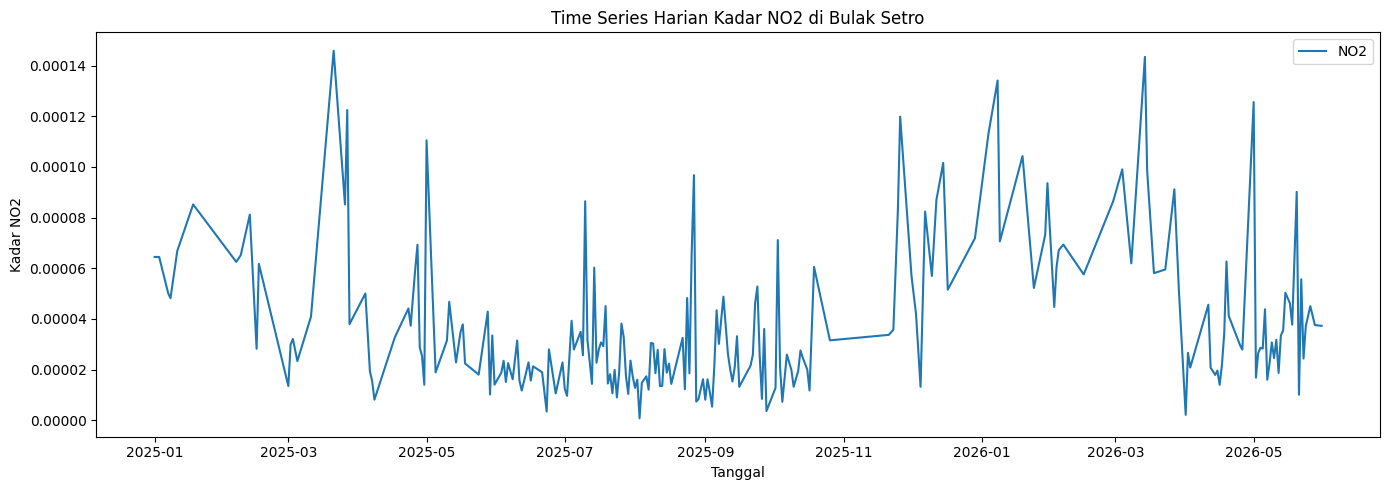

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df_ts["date"], df_ts["NO2"], label="NO2")
plt.title("Time Series Harian Kadar NO2 di Bulak Setro")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Deteksi Outlier dengan Metode IQR

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)**.

Rumus batas outlier:

- `Q1` = kuartil pertama.
- `Q3` = kuartil ketiga.
- `IQR = Q3 - Q1`.
- Batas bawah = `Q1 - 1.5 × IQR`.
- Batas atas = `Q3 + 1.5 × IQR`.

Data yang berada di bawah batas bawah atau di atas batas atas dianggap sebagai outlier.

In [11]:
Q1 = df_ts["NO2"].quantile(0.25)
Q3 = df_ts["NO2"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_ts[(df_ts["NO2"] < lower_bound) | (df_ts["NO2"] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Jumlah outlier:", len(outliers))
outliers.head(10)

Q1: 2.287182610416494e-05
Q3: 6.700552830807283e-05
IQR: 4.413370220390789e-05
Lower Bound: -4.332872720169689e-05
Upper Bound: 0.00013320608161393466
Jumlah outlier: 5


,date,NO2
78,2025-03-20,0.000135
79,2025-03-21,0.000146
80,2025-03-22,0.000134
372,2026-01-08,0.000134
437,2026-03-14,0.000143


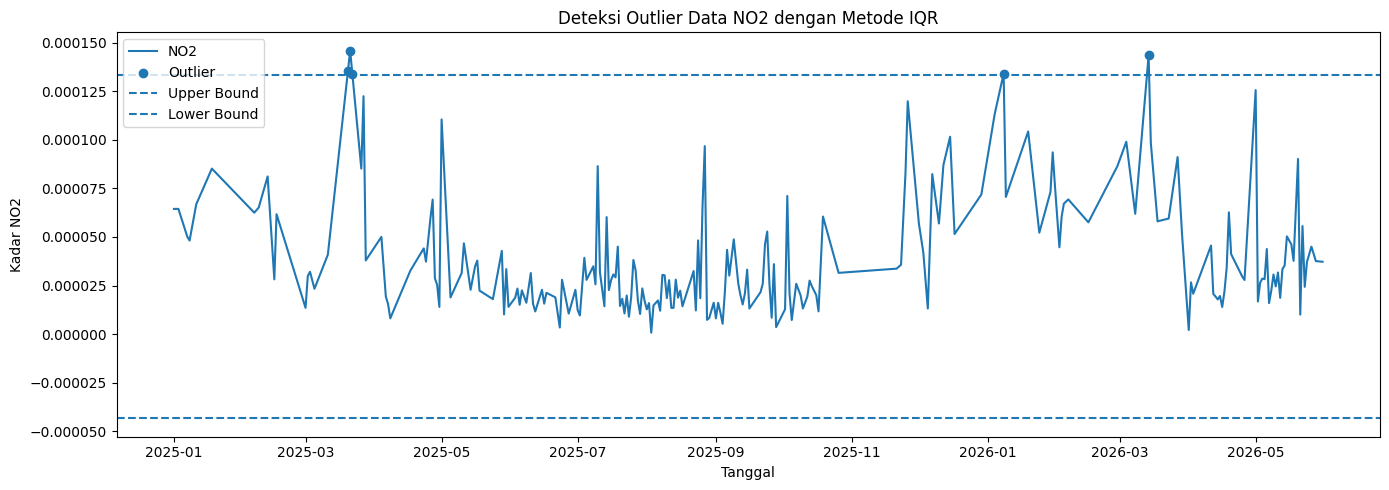

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df_ts["date"], df_ts["NO2"], label="NO2")
plt.scatter(outliers["date"], outliers["NO2"], label="Outlier")
plt.axhline(upper_bound, linestyle="--", label="Upper Bound")
plt.axhline(lower_bound, linestyle="--", label="Lower Bound")
plt.title("Deteksi Outlier Data NO2 dengan Metode IQR")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Membersihkan Outlier

Outlier tidak langsung dihapus dari urutan tanggal, tetapi diganti menjadi `NaN`, lalu diisi kembali menggunakan interpolasi. Cara ini dipilih agar pola time series tetap berurutan harian dan tidak ada tanggal yang hilang.

In [13]:
df_clean = df_ts.copy()
mask_outlier = (df_clean["NO2"] < lower_bound) | (df_clean["NO2"] > upper_bound)

df_clean["NO2_cleaned"] = df_clean["NO2"].mask(mask_outlier)
df_clean["NO2_filled"] = df_clean["NO2_cleaned"].interpolate(method="linear").bfill().ffill()

print("Jumlah outlier yang diganti NaN:", df_clean["NO2_cleaned"].isna().sum())
print("Jumlah missing setelah interpolasi:", df_clean["NO2_filled"].isna().sum())
df_clean.head()

Jumlah outlier yang diganti NaN: 5
Jumlah missing setelah interpolasi: 0


,date,NO2,NO2_cleaned,NO2_filled
0,2025-01-01,0.000064,0.000064,0.000064
1,2025-01-02,0.000064,0.000064,0.000064
2,2025-01-03,0.000064,0.000064,0.000064
3,2025-01-04,0.000061,0.000061,0.000061
4,2025-01-05,0.000057,0.000057,0.000057


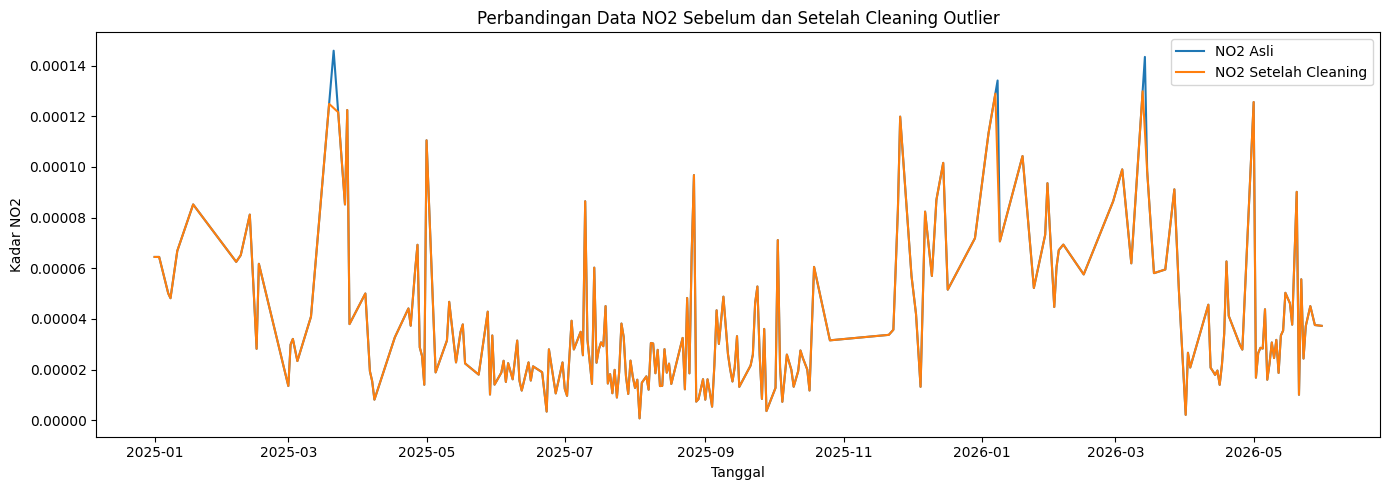

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean["date"], df_clean["NO2"], label="NO2 Asli")
plt.plot(df_clean["date"], df_clean["NO2_filled"], label="NO2 Setelah Cleaning")
plt.title("Perbandingan Data NO2 Sebelum dan Setelah Cleaning Outlier")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Normalisasi Data

Model KNN menghitung jarak antar data. Karena itu, data dinormalisasi menggunakan **Min-Max Scaler** agar nilainya berada pada rentang 0 sampai 1.

In [11]:
scaler = MinMaxScaler()
df_clean["NO2_scaled"] = scaler.fit_transform(df_clean[["NO2_filled"]])

df_clean[["date", "NO2_filled", "NO2_scaled"]].head()

,date,NO2_filled,NO2_scaled
0,2025-01-01,0.000064,0.493486
1,2025-01-02,0.000064,0.493486
2,2025-01-03,0.000064,0.493486
3,2025-01-04,0.000061,0.465669
4,2025-01-05,0.000057,0.437852


## 9. Membentuk Data Supervised Learning

Data time series diubah menjadi format supervised learning dengan teknik **lag feature**.

Contoh untuk `n_lag = 4`:

| NO2(t-4) | NO2(t-3) | NO2(t-2) | NO2(t-1) | NO2(t) |
|---|---|---|---|---|
| data 4 hari sebelumnya | data 3 hari sebelumnya | data 2 hari sebelumnya | data 1 hari sebelumnya | target hari ini |

Kolom `NO2(t)` menjadi target prediksi, sedangkan kolom lag menjadi fitur input.

In [12]:
def create_supervised(series, n_lag=4):
    """Mengubah data deret waktu menjadi data supervised learning berbasis lag."""
    supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        supervised[f"NO2(t-{i})"] = series.shift(i)

    supervised["NO2(t)"] = series.values
    supervised = supervised.dropna().reset_index(drop=True)
    return supervised

supervised_4 = create_supervised(df_clean["NO2_scaled"], n_lag=4)
supervised_10 = create_supervised(df_clean["NO2_scaled"], n_lag=10)
supervised_30 = create_supervised(df_clean["NO2_scaled"], n_lag=30)

print("Shape supervised lag 4:", supervised_4.shape)
print("Shape supervised lag 10:", supervised_10.shape)
print("Shape supervised lag 30:", supervised_30.shape)
supervised_4.head()

Shape supervised lag 4: (512, 5)
Shape supervised lag 10: (506, 11)
Shape supervised lag 30: (486, 31)


,NO2(t-4),NO2(t-3),NO2(t-2),NO2(t-1),NO2(t)
0,0.493486,0.493486,0.493486,0.465669,0.437852
1,0.493486,0.493486,0.465669,0.437852,0.410035
2,0.493486,0.465669,0.437852,0.410035,0.382218
3,0.465669,0.437852,0.410035,0.382218,0.367362
4,0.437852,0.410035,0.382218,0.367362,0.415591


## 10. Korelasi Lag terhadap Target

Korelasi digunakan untuk melihat hubungan antara nilai NO₂ hari sebelumnya dengan nilai NO₂ hari ini. Semakin besar nilai korelasi, semakin kuat hubungan lag tersebut terhadap target.

In [13]:
correlations = supervised_30.drop(columns="NO2(t)").corrwith(supervised_30["NO2(t)"])
correlation_table = correlations.reset_index()
correlation_table.columns = ["Lag", "Correlation"]
correlation_table

,Lag,Correlation
0,NO2(t-30),0.285093
1,NO2(t-29),0.283400
2,NO2(t-28),0.280705
3,NO2(t-27),0.282560
4,NO2(t-26),0.275063
5,NO2(t-25),0.282654
6,NO2(t-24),0.272913
7,NO2(t-23),0.269487
8,NO2(t-22),0.266890
9,NO2(t-21),0.268150


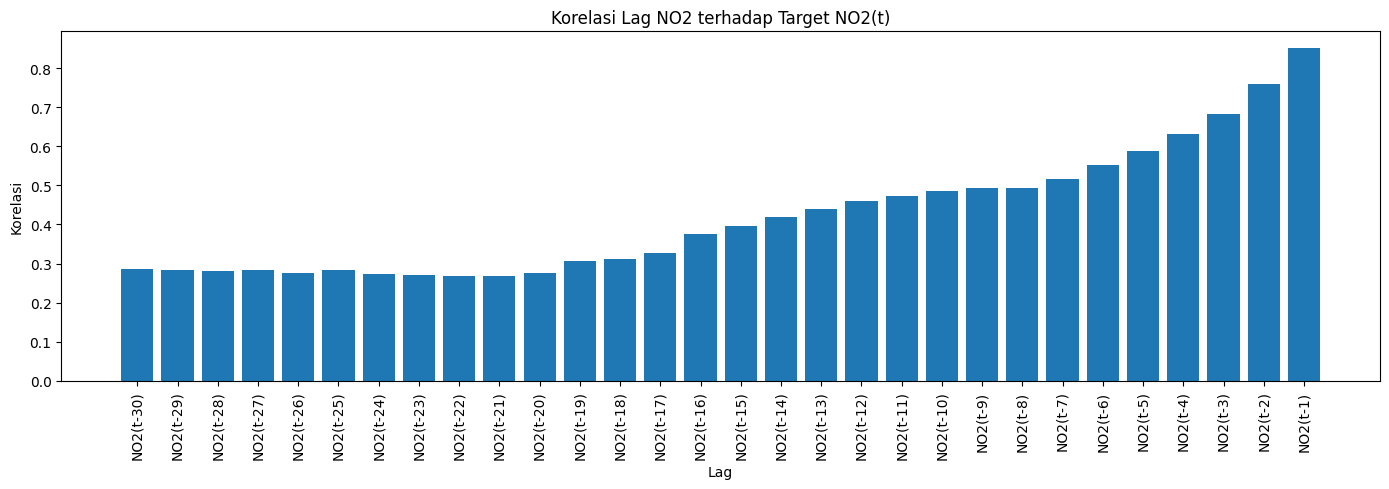

In [14]:
plt.figure(figsize=(14, 5))
plt.bar(correlation_table["Lag"], correlation_table["Correlation"])
plt.xticks(rotation=90)
plt.title("Korelasi Lag NO2 terhadap Target NO2(t)")
plt.xlabel("Lag")
plt.ylabel("Korelasi")
plt.tight_layout()
plt.show()

## 11. Modeling KNN Regression

Data dibagi menjadi data latih dan data uji dengan perbandingan 80:20. Karena data berupa time series, pembagian dilakukan tanpa `shuffle`, sehingga urutan waktu tetap terjaga.

Model yang digunakan adalah **KNeighborsRegressor** dengan `n_neighbors = 5`.

In [15]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100


def train_knn(df_supervised, n_neighbors=5, model_name="KNN"):
    X = df_supervised.drop(columns=["NO2(t)"]).values
    y = df_supervised["NO2(t)"].values

    split_index = int(len(df_supervised) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    model = KNeighborsRegressor(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape_value = mape(y_test, y_pred)

    result = {
        "Model": model_name,
        "Lag": X.shape[1],
        "K": n_neighbors,
        "Train Size": len(X_train),
        "Test Size": len(X_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE (%)": mape_value
    }

    return model, y_test, y_pred, result

model_4, y_test_4, y_pred_4, result_4 = train_knn(supervised_4, n_neighbors=5, model_name="KNN Lag 4")
model_10, y_test_10, y_pred_10, result_10 = train_knn(supervised_10, n_neighbors=5, model_name="KNN Lag 10")
model_30, y_test_30, y_pred_30, result_30 = train_knn(supervised_30, n_neighbors=5, model_name="KNN Lag 30")

results = pd.DataFrame([result_4, result_10, result_30])
results

,Model,Lag,K,Train Size,Test Size,RMSE,MAE,R2,MAPE (%)
0,KNN Lag 4,4,5,409,103,0.137402,0.088029,0.614085,52.014727
1,KNN Lag 10,10,5,404,102,0.154469,0.107896,0.516368,81.427466
2,KNN Lag 30,30,5,388,98,0.175269,0.129111,0.393855,92.401361


## 12. Visualisasi Hasil Prediksi

Nilai aktual dan prediksi ditampilkan dalam skala asli NO₂ dengan cara mengembalikan hasil normalisasi menggunakan `inverse_transform`.

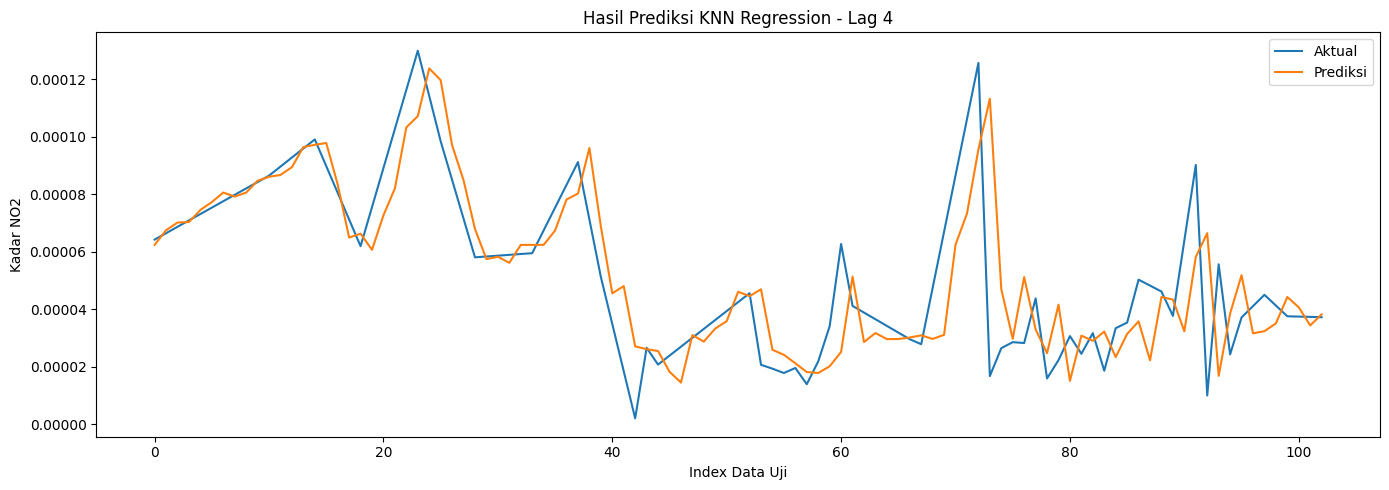

In [16]:
def inverse_scale(values):
    return scaler.inverse_transform(np.array(values).reshape(-1, 1)).ravel()

actual_4 = inverse_scale(y_test_4)
pred_4 = inverse_scale(y_pred_4)

actual_10 = inverse_scale(y_test_10)
pred_10 = inverse_scale(y_pred_10)

actual_30 = inverse_scale(y_test_30)
pred_30 = inverse_scale(y_pred_30)

plt.figure(figsize=(14, 5))
plt.plot(actual_4, label="Aktual")
plt.plot(pred_4, label="Prediksi")
plt.title("Hasil Prediksi KNN Regression - Lag 4")
plt.xlabel("Index Data Uji")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

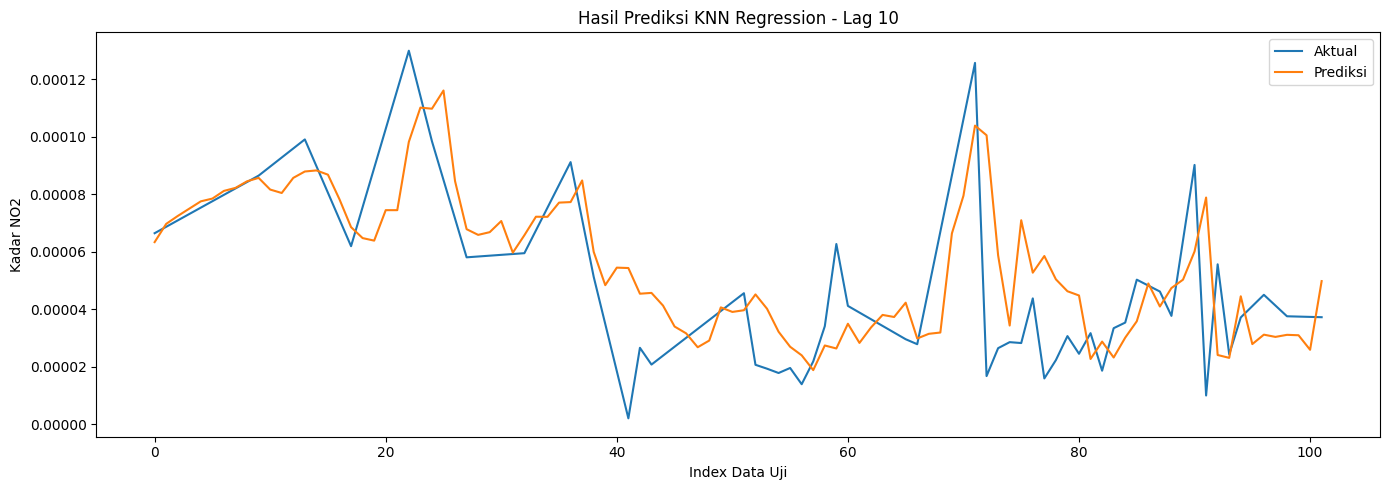

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(actual_10, label="Aktual")
plt.plot(pred_10, label="Prediksi")
plt.title("Hasil Prediksi KNN Regression - Lag 10")
plt.xlabel("Index Data Uji")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

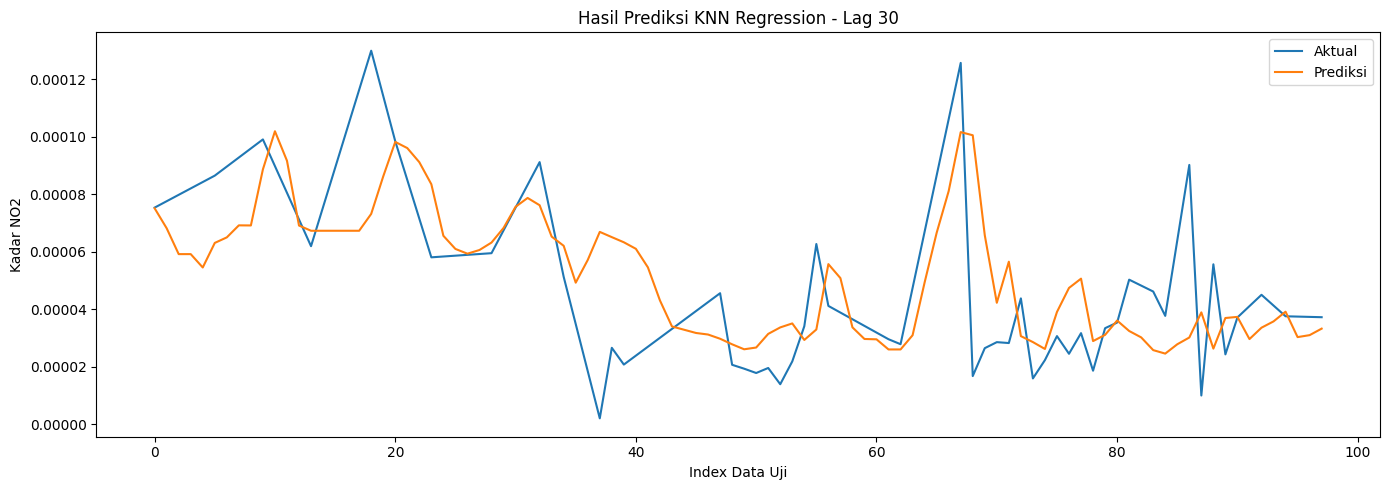

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(actual_30, label="Aktual")
plt.plot(pred_30, label="Prediksi")
plt.title("Hasil Prediksi KNN Regression - Lag 30")
plt.xlabel("Index Data Uji")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Perbandingan Evaluasi Model

Model dengan nilai **RMSE**, **MAE**, dan **MAPE** lebih kecil menunjukkan error yang lebih rendah. Nilai **R²** yang lebih tinggi menunjukkan kemampuan model yang lebih baik dalam menjelaskan variasi data.

In [19]:
results_sorted = results.sort_values(by="RMSE").reset_index(drop=True)
results_sorted

,Model,Lag,K,Train Size,Test Size,RMSE,MAE,R2,MAPE (%)
0,KNN Lag 4,4,5,409,103,0.137402,0.088029,0.614085,52.014727
1,KNN Lag 10,10,5,404,102,0.154469,0.107896,0.516368,81.427466
2,KNN Lag 30,30,5,388,98,0.175269,0.129111,0.393855,92.401361


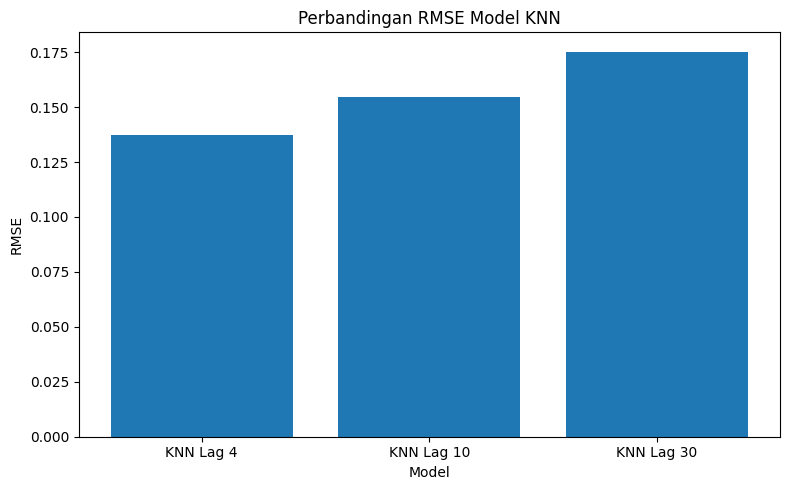

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Perbandingan RMSE Model KNN")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

## 14. Kesimpulan

Berdasarkan proses yang telah dilakukan, tahapan analisis data NO₂ adalah sebagai berikut:

1. Data NO₂ dibaca dari file NetCDF.
2. Data dikonversi menjadi time series harian.
3. Missing value diisi dengan interpolasi waktu.
4. Outlier dideteksi menggunakan metode IQR.
5. Outlier diganti dengan interpolasi agar urutan tanggal tetap lengkap.
6. Data dinormalisasi menggunakan Min-Max Scaler.
7. Data time series diubah menjadi data supervised menggunakan lag.
8. Model KNN Regression dilatih dan dievaluasi.
9. Performa model dibandingkan berdasarkan RMSE, MAE, R², dan MAPE.

Notebook ini sudah siap dijalankan di VS Code/Jupyter. Pastikan file `NO2bulaksetro.nc` atau `openEO.nc` berada di folder yang sama dengan notebook.